In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.physics.traveltime as tt
from tt_utils import createCrossholeData

In [2]:
data = createCrossholeData(x=[0, 10], z=[-3, -2, -1])
np.column_stack((data["s"], data["g"]))

array([[0, 3],
       [0, 4],
       [0, 5],
       [1, 3],
       [1, 4],
       [1, 5],
       [2, 3],
       [2, 4],
       [2, 5]])

In [3]:
data.sensors().array()

array([[ 0., -3.,  0.],
       [ 0., -2.,  0.],
       [ 0., -1.,  0.],
       [10., -3.,  0.],
       [10., -2.,  0.],
       [10., -1.,  0.]])

Mesh: Nodes: 143 Cells: 120 Boundaries: 262


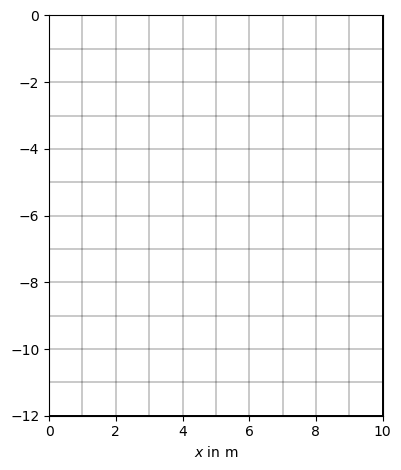

In [39]:
x = np.arange(10.1)  # 0 1 .. 10
y = -np.arange(0, 12.1)  # 0 1 .. 11
grid = pg.createGrid(x, y)
print(grid)
pg.show(grid);

Data: Sensors: 24 data: 144, nonzero entries: ['g', 's', 'valid']


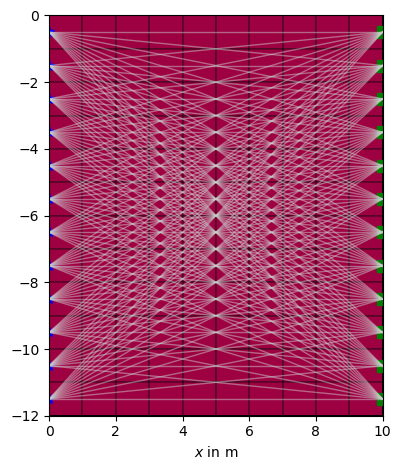

In [40]:
data = tt.createCrossholeData(x=[0, 10], z=-np.arange(12)-0.5)
print(data)
ax, cb = grid.show(grid.cellMarkers(), showMesh=1,
                   colorBar=False, cMap="Spectral")
sx = pg.x(data)
sy = pg.y(data)
sC = data.sensorCount()
ax.plot(sx[:sC//2], sy[:sC//2], "b*", ms=8)
ax.plot(sx[sC//2:], sy[sC//2:], "gs", ms=8)
# ax.figure.savefig("crosshole-setup.svg")
for s, g in zip(data["s"], data["g"]):
    ax.plot([sx[s], sx[g]], [sy[s], sy[g]],
            color="0.8", alpha=0.5, lw=1)
# ax.figure.savefig("crosshole-raypaths.svg")

26/05/26 - 18:59:45 - pyGIMLi - INFO - Creating refined mesh (secnodes: 5) to solve forward task.


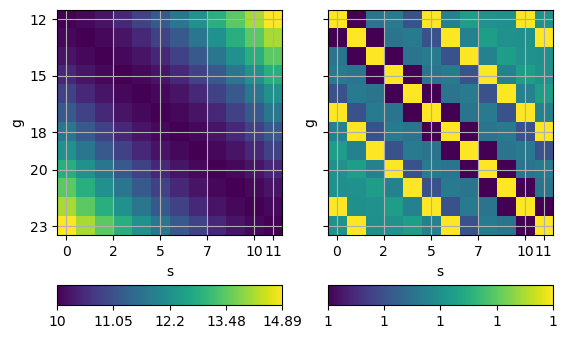

In [41]:
grid["slowness"] = 1.0
data = tt.simulate(mesh=grid, scheme=data, slowness=grid["slowness"], secNodes=5) # , noiseLevel=0.001, noiseAbs=1e-5)
data["va"] = tt.shotReceiverDistances(data) / data["t"]
data.save("data.dat", "s g t")
data["err"] = 0.1
fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
pg.viewer.mpl.showDataContainerAsMatrix(data, "s", "g", "t", ax=ax[0]);
pg.viewer.mpl.showDataContainerAsMatrix(data, "s", "g", "va", ax=ax[1]);

In [42]:
min(data["va"]), max(data["va"])

(0.9967383037061017, 1.0)

In [43]:
fop = tt.TravelTimeModelling(secNodes=5)
fop.setData(data)
fop.setMesh(grid)
fop.createJacobian(grid["slowness"])


26/05/26 - 18:59:48 - pyGIMLi - INFO - Found 1 regions.
26/05/26 - 18:59:48 - pyGIMLi - INFO - Creating forward mesh from region infos.
26/05/26 - 18:59:48 - pyGIMLi - INFO - Creating refined mesh (secnodes: 5) to solve forward task.


In [50]:
G = pg.utils.sparseMatrix2csr(fop.jacobian())
print(G)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1786 stored elements and shape (144, 120)>
  Coords	Values
  (0, 0)	1.0
  (0, 1)	1.0
  (0, 2)	1.0
  (0, 3)	1.0
  (0, 4)	1.0
  (0, 5)	1.0
  (0, 6)	1.0
  (0, 7)	1.0
  (0, 8)	1.0
  (0, 9)	1.0
  (1, 0)	1.0137937550497031
  (1, 1)	1.0137937550497034
  (1, 2)	1.0
  (1, 3)	1.0137937550497031
  (1, 4)	0.5
  (1, 5)	0.5
  (1, 14)	0.5
  (1, 15)	0.5
  (1, 16)	1.0137937550497034
  (1, 17)	1.0137937550497031
  (1, 18)	1.0137937550497034
  (1, 19)	1.0
  (2, 0)	1.0137937550497031
  (2, 1)	1.0137937550497034
  (2, 2)	1.0137937550497031
  :	:
  (141, 111)	1.0137937550497034
  (141, 112)	1.0137937550497031
  (142, 103)	0.5
  (142, 104)	0.5
  (142, 105)	0.5
  (142, 106)	1.0137937550497031
  (142, 107)	1.0137937550497034
  (142, 108)	1.0137937550497031
  (142, 109)	1.0
  (142, 110)	1.0137937550497031
  (142, 111)	1.0137937550497034
  (142, 112)	1.0137937550497031
  (142, 113)	0.5
  (142, 114)	0.5
  (142, 115)	0.5
  (143, 110)	1.0
  (143, 111)	1.

In [51]:
grid["slowness"]

120 [1.0,...,1.0]

In [52]:
s = np.ones(grid.cellCount())
G.shape, s.shape
G@s

array([10.        , 10.08276253, 10.21853515, 10.46032794, 10.79669128,
       11.18033989, 11.68323851, 12.22427911, 12.8269703 , 13.47552578,
       14.14213562, 14.88973935, 10.08276253, 10.        , 10.08276253,
       10.21853515, 10.46032794, 10.79669128, 11.18033989, 11.68323851,
       12.22427911, 12.8269703 , 13.47552578, 14.14213562, 10.21853515,
       10.08276253, 10.        , 10.08276253, 10.21853515, 10.46032794,
       10.79669128, 11.18033989, 11.68323851, 12.22427911, 12.8269703 ,
       13.47552578, 10.46032794, 10.21853515, 10.08276253, 10.        ,
       10.08276253, 10.21853515, 10.46032794, 10.79669128, 11.18033989,
       11.68323851, 12.22427911, 12.8269703 , 10.79669128, 10.46032794,
       10.21853515, 10.08276253, 10.        , 10.08276253, 10.21853515,
       10.46032794, 10.79669128, 11.18033989, 11.68323851, 12.22427911,
       11.18033989, 10.79669128, 10.46032794, 10.21853515, 10.08276253,
       10.        , 10.08276253, 10.21853515, 10.46032794, 10.79

In [53]:
data["t"] = np.ravel(G@grid["slowness"])

In [54]:
G.shape, G.dot(s).shape

((144, 120), (144,))

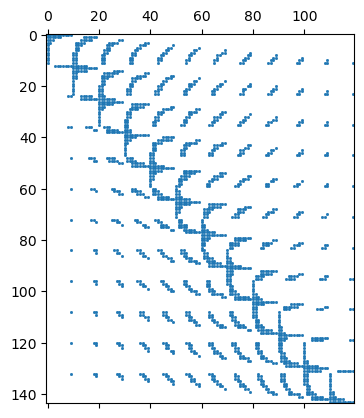

In [57]:
plt.spy(G, ms=1)

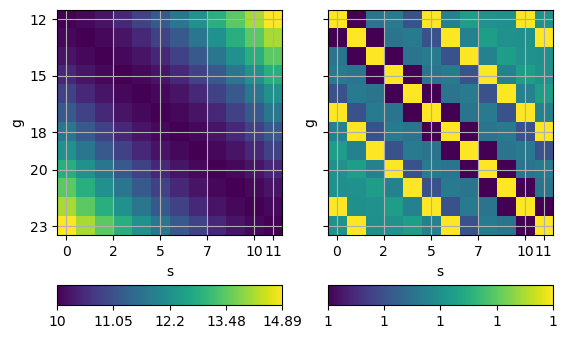

In [55]:
va = tt.shotReceiverDistances(data) / data["t"]
fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
pg.viewer.mpl.showDataContainerAsMatrix(data, "s", "g", "t", ax=ax[0]);
pg.viewer.mpl.showDataContainerAsMatrix(data, "s", "g", "va", ax=ax[1]);

20/05/26 - 07:54:18 - pyGIMLi - INFO - Found 1 regions.
20/05/26 - 07:54:18 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/05/26 - 07:54:18 - pyGIMLi - INFO - Creating refined mesh (secnodes: 10) to solve forward task.


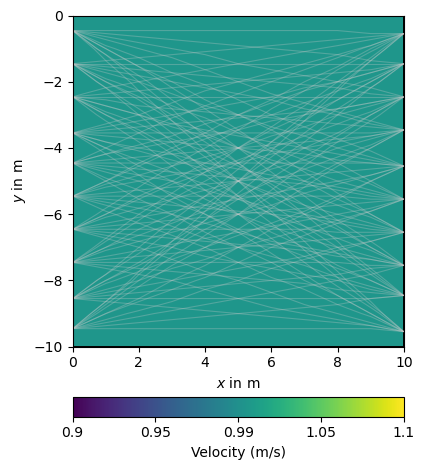

In [ ]:
# mgr = tt.TravelTimeManager(data, secNodes=10)
# mgr.setMesh(grid, secNodes=10)
# mgr.invert(maxIter=0, startModel=1);
# ax, cbar = mgr.showResult();
# mgr.drawRayPaths(ax=ax, color="0.8", alpha=0.3);

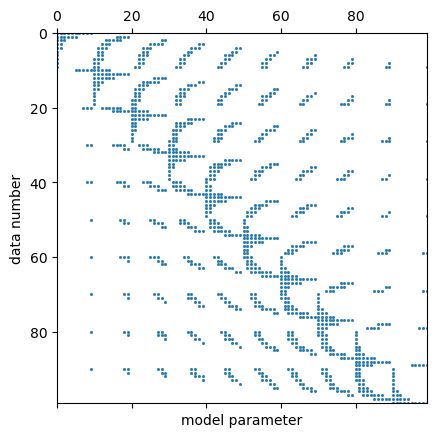

In [ ]:
# J = mgr.fop.jacobian()
# ax, cb = pg.show(J, ms=1)
# ax.set_aspect(1.0)
# ax.set_xlabel("model parameter")
# ax.set_ylabel("data number")
# ax.figure.savefig("xh-jacobian.svg")
# J.save("jacobian.ijv")

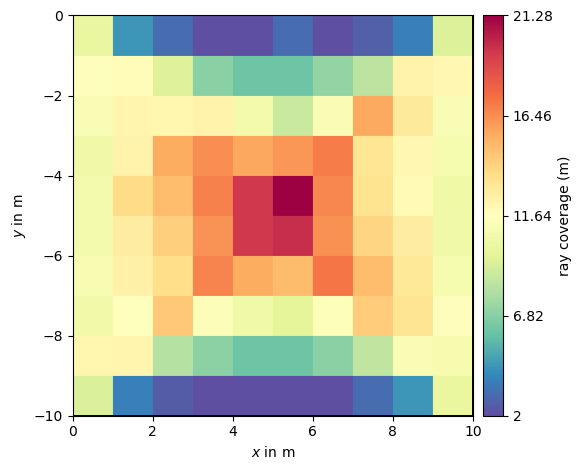

In [ ]:
coverage = mgr.rayCoverage()
ax, cb = grid.show(coverage, label="ray coverage (m)", orientation="vertical", cMap="Spectral_r")
ax.figure.savefig("xh-coverage.svg")

In [ ]:
G = pg.utils.sparseMatrix2csr(J).todense()
print(G)

[[1.         1.         1.         ... 0.         0.         0.        ]
 [1.00412373 1.00412373 1.00412373 ... 0.         0.         0.        ]
 [1.01639454 1.01639454 1.01639454 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 1.         1.         1.00412373]]


In [ ]:
U, s, Vh = np.linalg.svd(G)

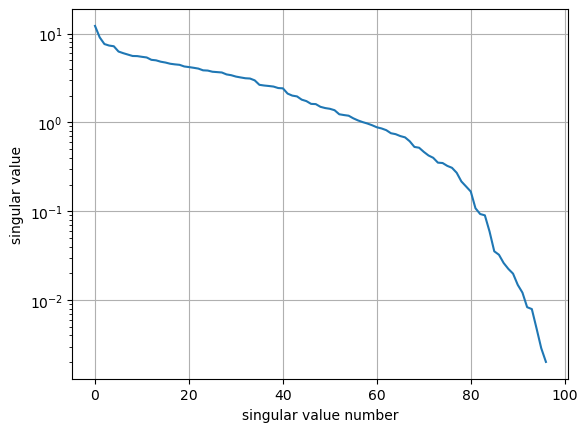

In [ ]:
fig, ax = plt.subplots()
ax.semilogy(s[s>1e-13])
ax.grid()
ax.set_xlabel("singular value number")
ax.set_ylabel("singular value")
fig.savefig("xh-sv.svg")

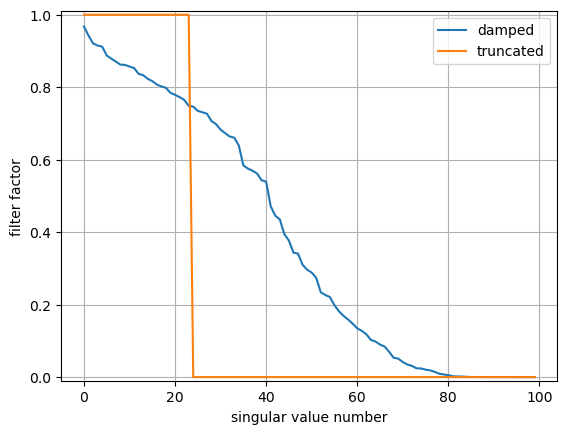

In [ ]:
lam = 5
f = s**2 / (s**2+lam)
fig, ax = plt.subplots()
ax.plot(f, label="damped")
ax.set_ylim(-0.01, 1.01)
ax.set_xlabel("singular value number")
ax.set_ylabel("filter factor")
ax.grid()
ff = np.ones_like(s)
ff[24:] = 0
ax.plot(ff, label="truncated")
ax.legend()
fig.savefig("xh-filterfactor.svg")

In [ ]:
# pg.viewer.mpl.showDataContainerAsMatrix(data, "s", "g", U[:, 4]);

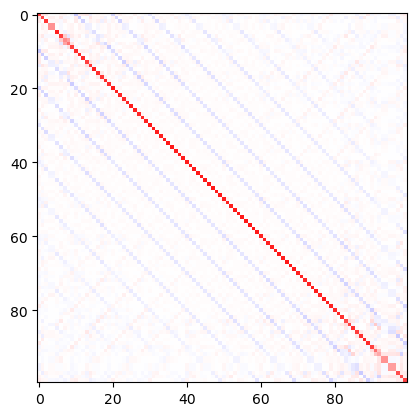

In [ ]:
RM = np.linalg.pinv(G, rcond=1e-2)@G
plt.imshow(RM, vmin=-1, vmax=1, cmap="bwr")
plt.gcf().savefig("xh-rm.svg")

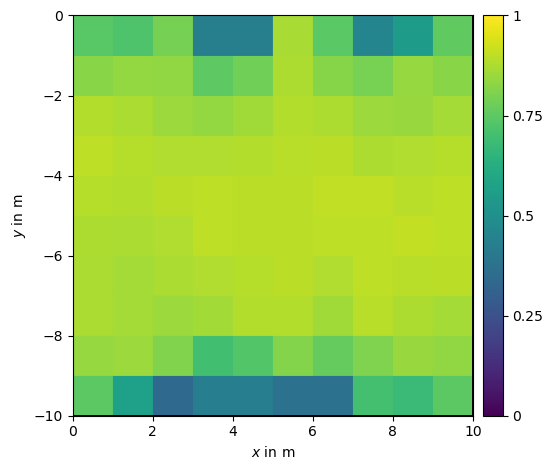

In [ ]:
ax, cb = grid.show(np.diag(RM), logScale=False, cMin=0, cMax=1, orientation="vertical");
ax.figure.savefig("xh-modelresolution.svg")

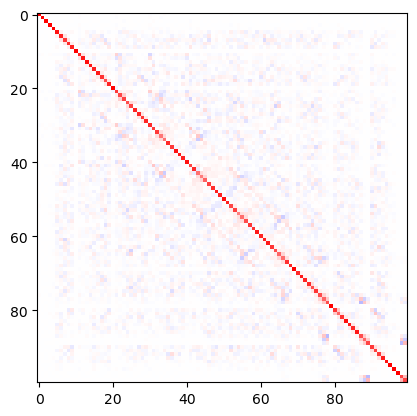

In [ ]:
RD = G@np.linalg.pinv(G, rcond=1e-2)
plt.imshow(RD, vmin=-1, vmax=1, cmap="bwr")
plt.gcf().savefig("xh-rd.svg")

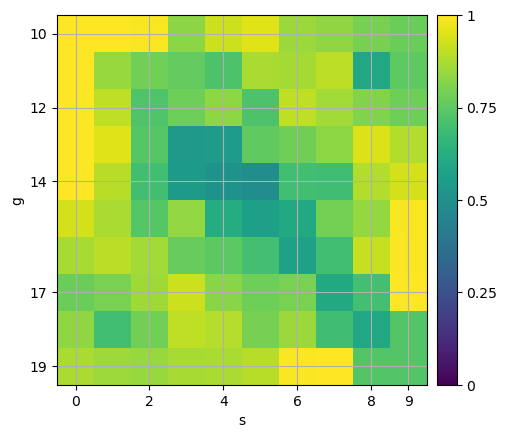

In [ ]:
ax, cb = pg.viewer.mpl.showDataContainerAsMatrix(
    data, "s", "g", np.diag(RD), cMin=0, cMax=1, orientation="vertical");
# ax.figure.savefig("xh-dataimportance.svg")

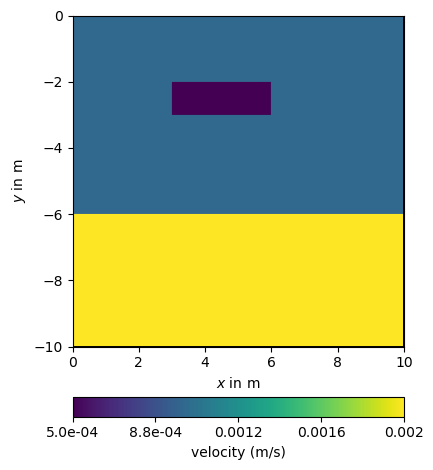

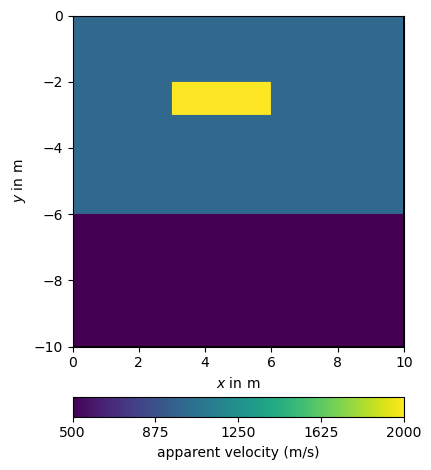

In [ ]:
# grid["slowness"] = 0.001
# slo = grid["slowness"]
slo = np.ones(grid.cellCount()) * 0.001
slo[int(grid.cellCount()//5*3):] = 0.002
slo[23:26] = 0.0005
grid["slowness"] = slo
ax, cb = grid.show("slowness", label="velocity (m/s)");
# ax.figure.savefig("xh-synmodels.svg")
ax, cb = grid.show(1/grid["slowness"], cMin=500, cMax=2000, label="apparent velocity (m/s)");
# ax.figure.savefig("xh-synmodelv.svg")

20/05/26 - 08:20:28 - pyGIMLi - INFO - Creating refined mesh (secnodes: 5) to solve forward task.


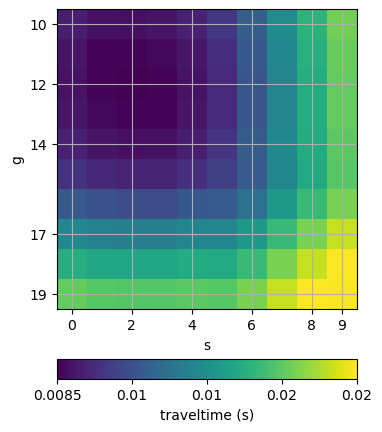

In [ ]:
data = tt.simulate(mesh=grid, scheme=data, slowness=grid["slowness"], secNodes=5) # , noiseLevel=0.001, noiseAbs=1e-5)
# data["err"] = 0.1
ax, cb = pg.viewer.mpl.showDataContainerAsMatrix(
    data, "s", "g", "t", label="traveltime (s)");
# ax.figure.savefig("xh-datat.svg")

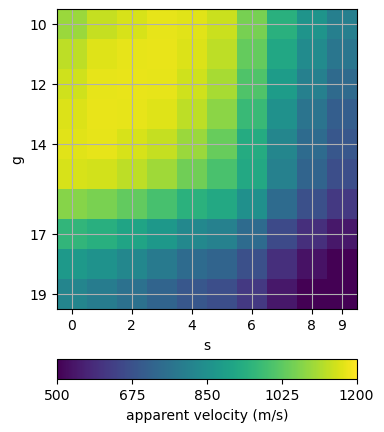

In [ ]:
data["va"] = tt.shotReceiverDistances(data) / data["t"]
ax, cb = pg.viewer.mpl.showDataContainerAsMatrix(
    data, "s", "g", data["va"], label="apparent velocity (m/s)", cMin=500, cMax=1200, logScale=False)
ax.figure.savefig("xh-datava.svg")

In [ ]:
noiseLevel = 0.0005
data["tn"] = data["t"] + np.random.randn(data.size()) * noiseLevel
m = np.zeros(grid.cellCount())

## TSVD reconstruction

In [ ]:
d = data["t"]  # "t" vs. "tn"
phiM = []
phiD = []
MOD = []
fig = plt.figure()
for i in range(60):
    m += np.ravel(Vh[i]) * (np.sum(U[:, i].T.dot(d)) / s[i])
    MOD.append(m*1.0)
    phiM.append(np.linalg.norm(m))
    dd = np.ravel(G@m-d)
    rms = np.sqrt(np.mean(dd**2))
    phiD.append(rms)
    if 0:
        fig.clf()
        ax = fig.add_subplot(111)
        # grid.show(m, ax=ax, cMin=0.001, cMax=0.002, logScale=False);
        grid.show(1/m, ax=ax, cMin=500, cMax=2000, logScale=True);
        ax.set_title(f"p={i:2d}")
        fig.savefig(f"xh/tsvd-model{i:02d}.svg");

<Figure size 640x480 with 0 Axes>

In [ ]:
grid["times"] = np.arange(len(MOD))
VMOD = 1.0 / np.array(MOD)
# out = pg.show(grid, VMOD, cMin=500, cMax=2000, orientation="vertical")
# out.save("xh/models.mp4")
# out.save("xh/models.mp4")

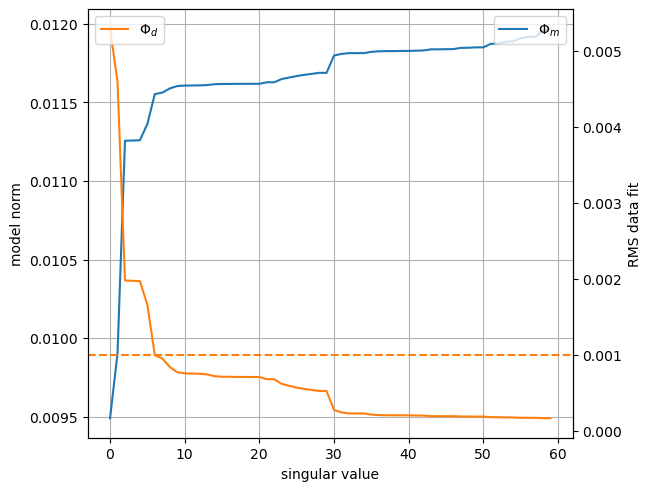

In [ ]:
fig, ax = plt.subplots(layout='constrained')
ax.plot(phiM, color="C0", label=r"$\Phi_m$")
ax.set_xlabel("singular value")
ax.set_ylabel("model norm")
ax2 = ax.twinx()
ax2.plot(phiD, color="C1", label=r"$\Phi_d$")
ax2.set_ylabel("RMS data fit")
ax.legend(loc="upper right")
ax2.legend(loc="upper left")
ax2.hlines(noiseLevel, *ax2.set_xlim(),
           ls="--", color="C1")
ax.grid()
fig.savefig("xh-modeldatanorm.svg")

## Damped normal equations

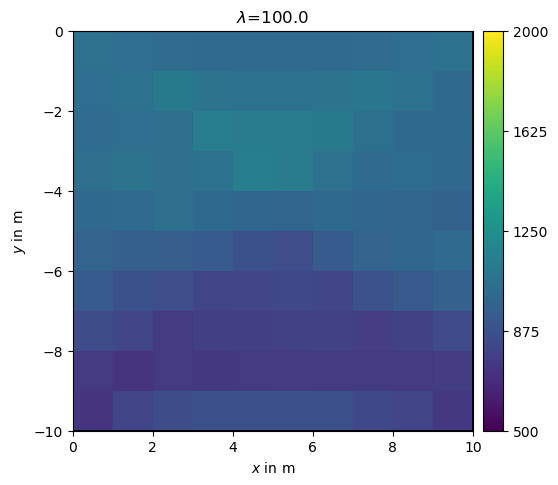

In [ ]:
d = np.array(data["tn"])
C = np.eye(len(m))
GTG = G.T@G
CTC = C.T@C
GTd = np.ravel((G.T@d))
c = np.ones(len(m)) * 0.001
CTc = (C.T@c).T
lams = np.logspace(-1, 2, 21)
fig = plt.figure()

phiM = []
phiD = []
for i, lam in enumerate(lams):
    m = np.ravel(np.linalg.inv(GTG+lam*CTC) @ (GTd + lam*CTc))
    phiM.append(np.linalg.norm(m-0.001))
    dd = np.ravel(G@m-d)
    rms = np.sqrt(np.mean(dd**2))
    phiD.append(rms)
    if 1:
        fig.clf()
        ax = fig.add_subplot(111)
        pg.show(grid, 1/m, ax=ax, cMin=500, cMax=2000, orientation="vertical")
        ax.set_title(fr"$\lambda$={lam:.1f}")
        fig.savefig(f"xh/xh-lam{lam:.1f}".replace(".", "_")+".svg")

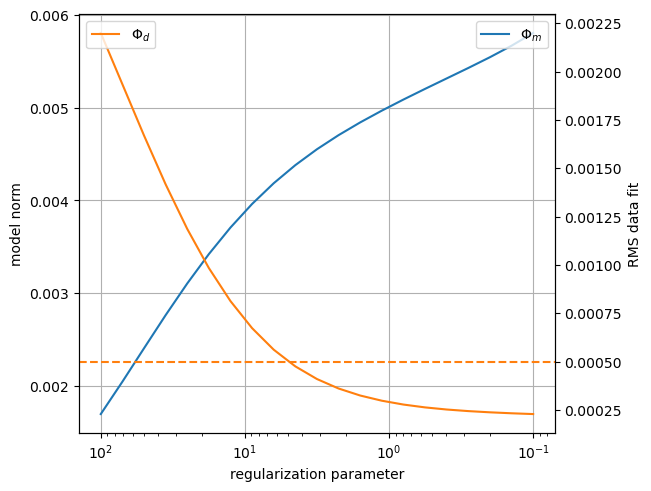

In [ ]:
fig, ax = plt.subplots(layout='constrained')
ax.semilogx(lams, phiM, color="C0", label=r"$\Phi_m$")
ax.set_xlim(ax.get_xlim()[::-1])
ax2 = ax.twinx()
ax2.semilogx(lams, phiD, color="C1", label=r"$\Phi_d$")
ax.set_xlabel("regularization parameter")
ax2.set_ylabel("RMS data fit")
ax.set_ylabel("model norm")
ax.legend(loc="upper right")
ax2.legend(loc="upper left")
ax2.hlines(noiseLevel, *ax2.set_xlim(),
           ls="--", color="C1")
ax.grid()
# fig.savefig("xhI-modeldatanorm.svg")

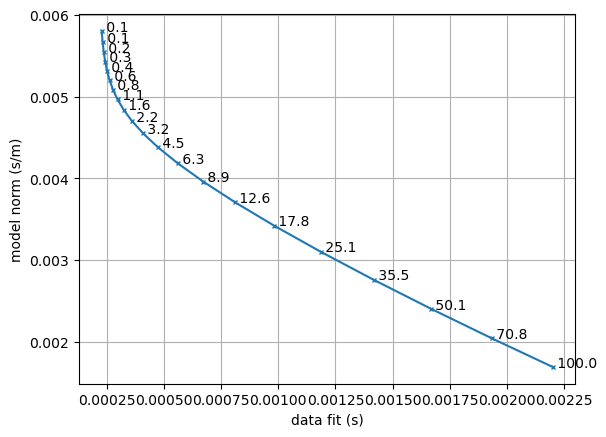

In [ ]:
fig, ax = plt.subplots()
ax.plot(phiD, phiM, "x-")
for i, lam in enumerate(lams):
    ax.text(phiD[i], phiM[i], f" {lam:.1f}")
ax.set_xlabel("data fit (s)")
ax.set_ylabel("model norm (s/m)")
ax.grid()
fig.savefig("xhI-Lcurve.svg")

## Smoothness constraints

In [ ]:
m = np.zeros(grid.cellCount())
d = np.array(data["tn"])
Cpg = mgr.fop.constraints()
C = pg.utils.sparseMatrix2csr(Cpg).todense()
GTG = G.T@G
CTC = C.T@C
GTd = np.ravel((G.T@d))
c = np.zeros(C.shape[0]) #  * 0.001
CTc = np.ravel(C.T@c)
print(C.shape, m.shape)
print(G.shape, m.shape, d.shape)
lams = np.logspace(-1, 2, 21)
fig = plt.figure()
phiM = []
phiD = []
for i, lam in enumerate(lams):
    m = np.ravel(np.linalg.inv(GTG+lam*CTC) @ (GTd + lam*CTc))
    phiM.append(np.linalg.norm(m-0.001))
    dd = np.ravel(G@m-d)
    rms = np.sqrt(np.mean(dd**2))
    phiD.append(rms)
    if 0:
        fig.clf()
        ax = fig.add_subplot(111)
        pg.show(grid, 1/m, ax=ax, cMin=500, cMax=2000, orientation="vertical")
        ax.set_title(fr"$\lambda$={lam:.1f}")
        fig.savefig(f"xh/xh-SC{lam:.1f}".replace(".", "_")+".svg")

(180, 100) (100,)
(100, 100) (100,) (100,)


<Figure size 640x480 with 0 Axes>

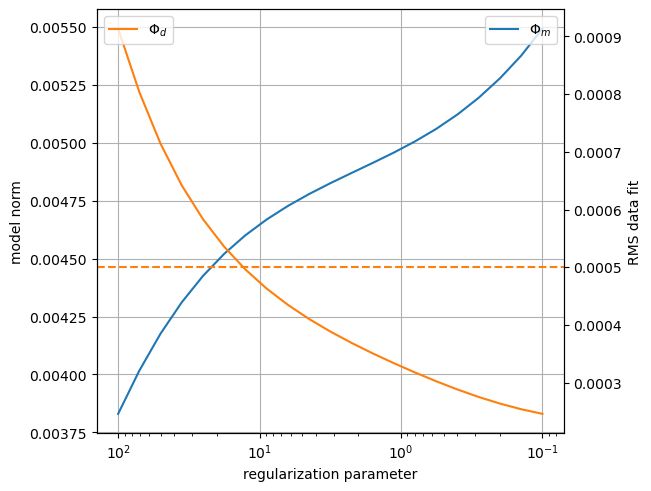

In [ ]:
fig, ax = plt.subplots(layout='constrained')
ax.semilogx(lams, phiM, color="C0", label=r"$\Phi_m$")
ax.set_xlim(ax.get_xlim()[::-1])
ax2 = ax.twinx()
ax2.semilogx(lams, phiD, color="C1", label=r"$\Phi_d$")
ax.set_xlabel("regularization parameter")
ax2.set_ylabel("RMS data fit")
ax.set_ylabel("model norm")
ax.legend(loc="upper right")
ax2.legend(loc="upper left")
ax2.hlines(noiseLevel, *ax2.set_xlim(),
           ls="--", color="C1")
ax.grid()
fig.savefig("xhS-modeldatanorm.svg")

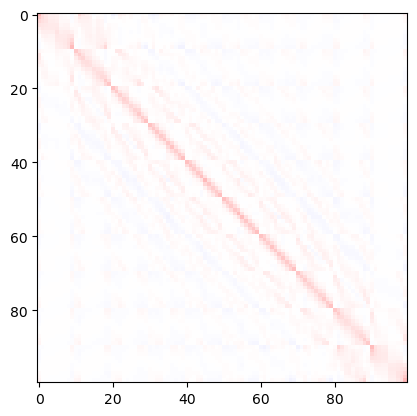

In [ ]:
lam = 10
RM = np.linalg.inv(GTG+lam*CTC) @ GTG
fig, ax = plt.subplots()
ax.imshow(RM, vmin=-1, vmax=1, cmap="bwr")
fig.savefig("xhS-rm.svg")

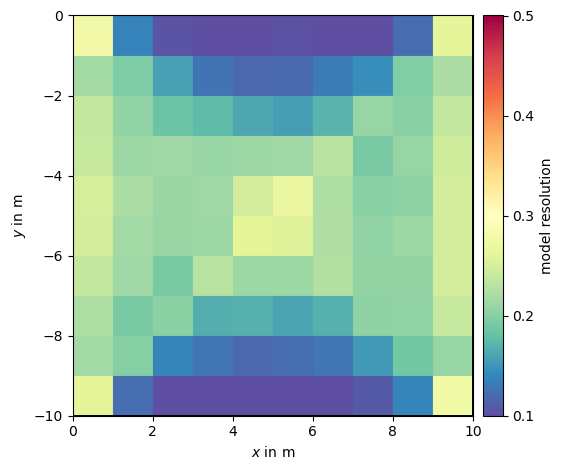

In [ ]:
ax, cb = grid.show(np.diag(RM), cMin=0.1, cMax=0.5, label="model resolution", orientation="vertical", cMap="Spectral_r")
ax.figure.savefig("xhS-rmdiag.svg")

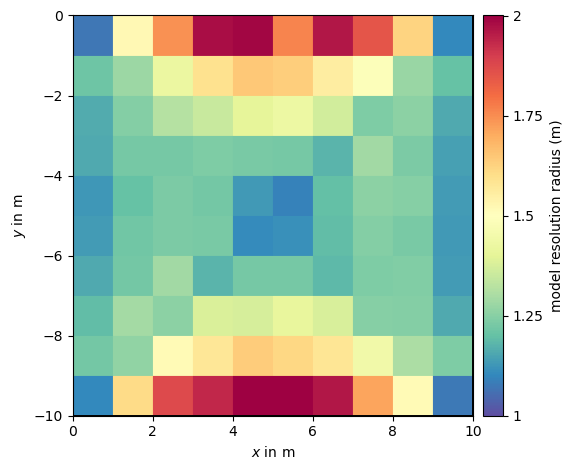

In [ ]:
rrad = np.sqrt(1/np.pi/np.diag(RM))
ax, cb = grid.show(rrad, cMin=1, cMax=2, label="model resolution radius (m)", orientation="vertical", cMap="Spectral_r")
ax.figure.savefig("xhS-resrad.svg")